In [1]:
import pandas as pd
import datetime as dt
import h5py
import numpy as np
import realtime_indices as rt
import dipole as dp

In [2]:
def read_hdf(fnm):
    with h5py.File(fnm, 'r') as f:
        cols=[i.decode("utf-8") for i in f['data']['axis0'][:].tolist()]
        inds=f['data']['axis1'][:]
        data=f['data']['block0_values'][:]
        df = pd.DataFrame(data, index=pd.to_datetime(inds, unit='ns'), columns=cols)
        df.replace(-99999, np.nan, inplace=True)
        df['Target_dt']=round((149.598-148.11)*1e6/df['Speed']/60.0)
    return df

In [3]:
def process_rtsw(path):
    data=pd.DataFrame()
    for i in range(2001,2025):
        try:
            new_data=read_hdf(path+str(i)+'.h5')
            data=pd.concat([data,new_data])
        except:
            continue
    # forward fill all nan values to a maximum of 10 minutes
    data.fillna(method='ffill', inplace=True,limit=10)
    # loop through all data with a 90 minute window and flag if there are any nan values in preceding 90 minutes
    data['nan_flag']=0
    data['seq_flag']=0
    for i in range(90,len(data)):
        if data.iloc[i-90:i+1].isnull().values.any():
            data.loc[data.index[i],'nan_flag']=1
        else:
            data.loc[data.index[i-90:i+1],'seq_flag']=1
    data.to_pickle(path+'processing.pkl')

In [4]:
process_rtsw('/mnt/disks/data/DSCOVR/dscovr_formatted_1m_')

/var/tmp/ipykernel_488621/1225557697.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True,limit=10)


In [5]:
process_rtsw('/mnt/disks/data/ACE/ace_formatted_1m_')

/var/tmp/ipykernel_488621/1225557697.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True,limit=10)


In [6]:
ace=pd.read_pickle('/mnt/disks/data/ACE/ace_formatted_1m_processing.pkl')
ace = ace[ace['seq_flag']==1]

In [7]:
dscovr=pd.read_pickle('/mnt/disks/data/DSCOVR/dscovr_formatted_1m_processing.pkl')
dscovr = dscovr[dscovr['seq_flag']==1]

In [8]:
strms=pd.read_csv('/mnt/disks/data/selected_data.csv',index_col=0,parse_dates=True)

In [9]:
ace_ind=ace.index.intersection(strms.index)
ace_sel=ace.loc[ace_ind]

dscovr_ind=dscovr.index.intersection(strms.index)
dscovr_sel=dscovr.loc[dscovr_ind]

In [10]:
ace_sel['Target_time']=ace_sel.index+pd.to_timedelta(ace_sel['Target_dt'],unit='m')
dscovr_sel['Target_time']=dscovr_sel.index+pd.to_timedelta(dscovr_sel['Target_dt'],unit='m')

In [37]:
ace_sel['Target']=~ace_sel.duplicated(subset='Target_time',keep='last')
dscovr_sel['Target']=~dscovr_sel.duplicated(subset='Target_time',keep='last')

In [38]:
ace_sel

,Speed,Density,Temperature,Bt,Bx,By,Bz,Target_dt,nan_flag,seq_flag,Target_time,Target
2001-08-11 15:27:00,392.8,0.9,84300.0,3.6,3.1,-1.3,1.0,63.0,0,1,2001-08-11 16:30:00,True
2001-08-11 15:28:00,369.9,1.3,174000.0,3.4,3.0,-1.3,0.9,67.0,0,1,2001-08-11 16:35:00,False
2001-08-11 15:29:00,386.4,0.9,87500.0,3.5,3.1,-1.3,0.9,64.0,0,1,2001-08-11 16:33:00,True
2001-08-11 15:30:00,378.0,1.0,117000.0,3.4,3.1,-1.4,0.8,66.0,0,1,2001-08-11 16:36:00,False
2001-08-11 15:31:00,389.7,0.9,159000.0,3.8,3.4,-1.4,1.0,64.0,0,1,2001-08-11 16:35:00,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31 05:59:00,370.7,8.8,50800.0,7.4,1.0,-7.3,-0.5,67.0,0,1,2024-05-31 07:06:00,True
2024-05-31 06:00:00,365.7,6.6,38700.0,7.0,1.2,-6.9,-0.0,68.0,0,1,2024-05-31 07:08:00,True
2024-05-31 06:01:00,348.9,3.6,22600.0,7.0,0.5,-6.9,-1.4,71.0,0,1,2024-05-31 07:12:00,True
2024-05-31 06:02:00,367.4,8.5,32700.0,6.2,-0.0,-5.9,-2.0,68.0,0,1,2024-05-31 07:10:00,True


In [12]:
ace_all=pd.DataFrame()
for i in range(2001,2025):
    try:
        new_data=read_hdf('/mnt/disks/data/ACE/ace_formatted_1m_'+str(i)+'.h5')
        ace_all=pd.concat([ace_all,new_data])
    except:
        continue

In [13]:
dscovr_all=pd.DataFrame()
for i in range(2001,2025):
    try:
        new_data=read_hdf('/mnt/disks/data/DSCOVR/dscovr_formatted_1m_'+str(i)+'.h5')
        dscovr_all=pd.concat([dscovr_all,new_data])
    except:
        continue

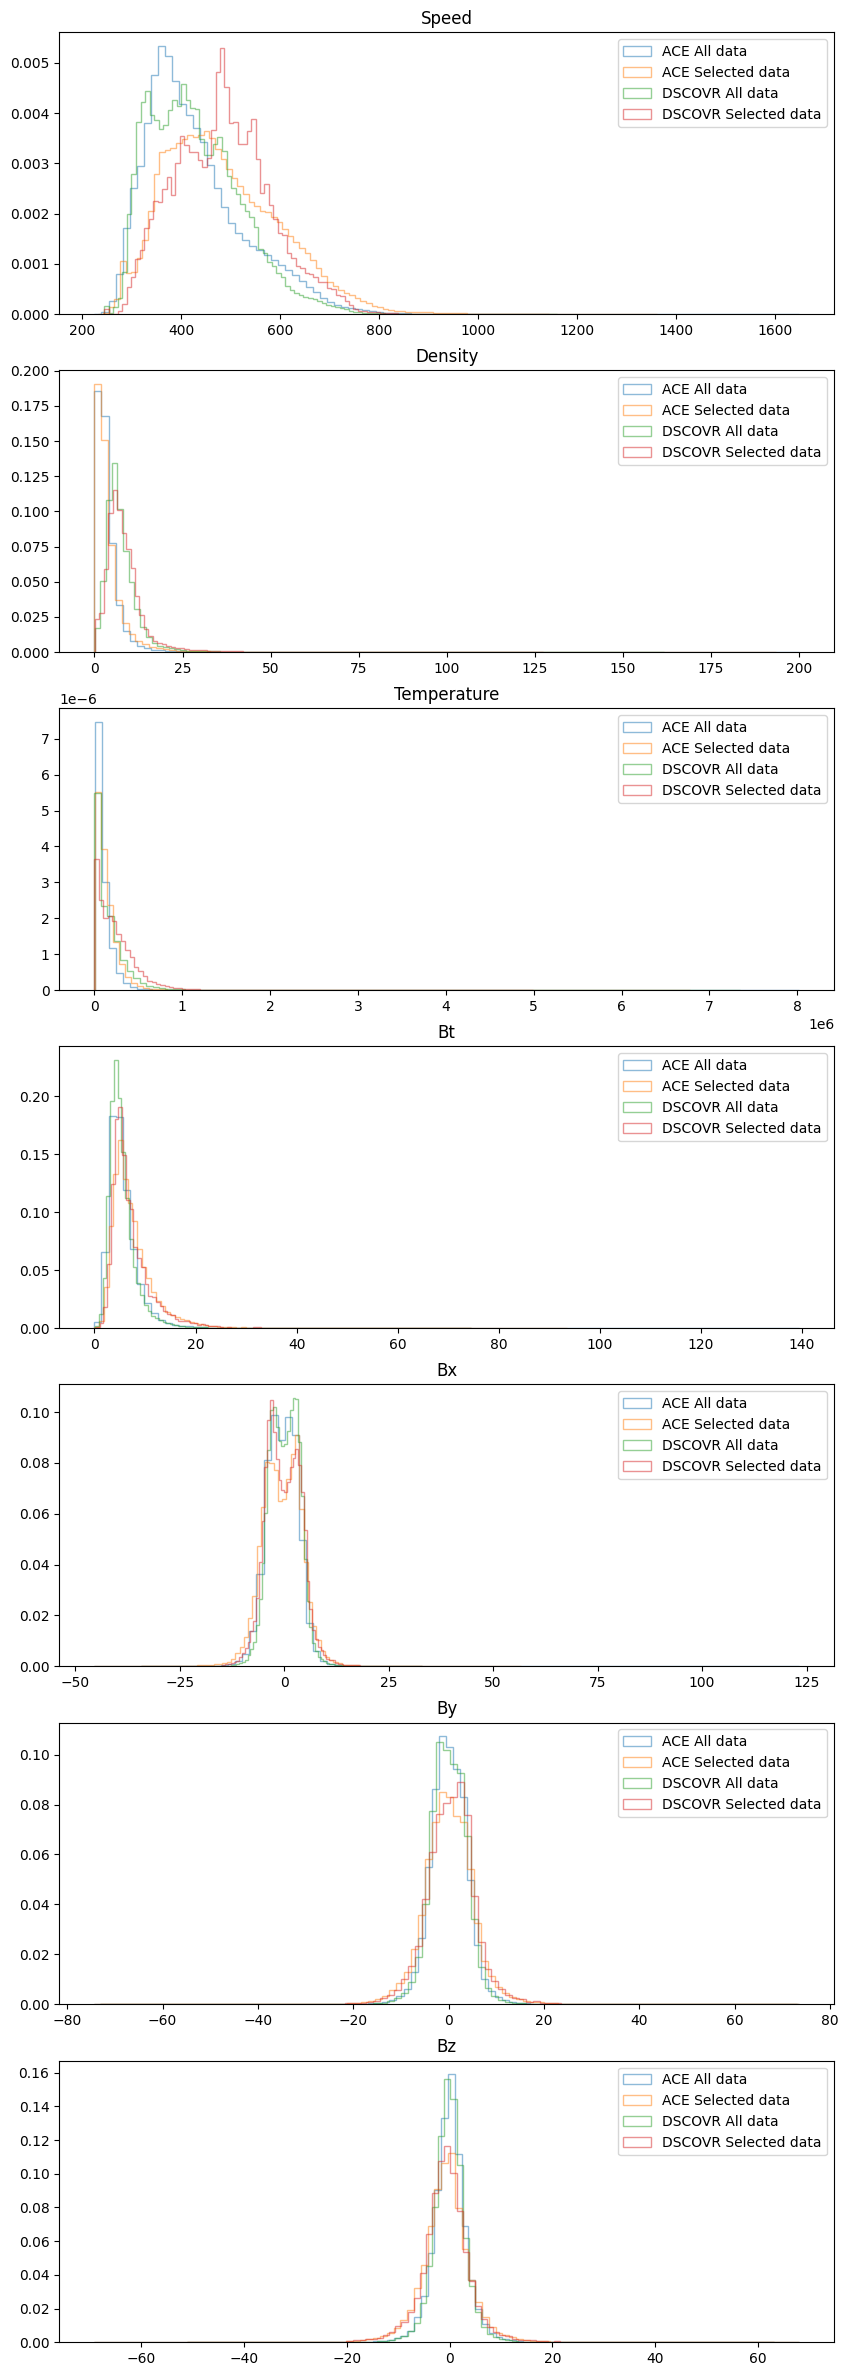

In [40]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(7,1,figsize=(10, 30))

for i, col in enumerate(['Speed','Density','Temperature','Bt','Bx','By','Bz']):
    axs[i%7].hist(ace_all[col], bins=100, alpha=0.5, label='ACE All data',histtype='step',density=True)
    axs[i%7].hist(ace_sel[col], bins=100, alpha=0.5, label='ACE Selected data',histtype='step',density=True)
    axs[i%7].hist(dscovr_all[col], bins=100, alpha=0.5, label='DSCOVR All data',histtype='step',density=True)
    axs[i%7].hist(dscovr_sel[col], bins=100, alpha=0.5, label='DSCOVR Selected data',histtype='step',density=True)
    axs[i%7].set_title(col)
    axs[i%7].legend()


In [39]:
ace_sel.to_pickle('/mnt/disks/data/ACE/ace_final.pkl')
dscovr_sel.to_pickle('/mnt/disks/data/DSCOVR/dscovr_final.pkl')

In [17]:
kp=rt.getKpindex('2001-08-10', '2024-06-30', 'Kp')
Hp30=rt.getKpindex('2001-08-10', '2024-06-30', 'Hp30')
ap30=rt.getKpindex('2001-08-10', '2024-06-30', 'ap30')
Fadj=rt.getKpindex('2001-08-10', '2024-06-30', 'Fadj')

In [18]:
kp_df=pd.DataFrame(index=pd.to_datetime(kp[0]),data=kp[1],columns=['Kp'])
Hp30_df=pd.DataFrame(index=pd.to_datetime(Hp30[0]),data=Hp30[1],columns=['Hp30'])
ap30_df=pd.DataFrame(index=pd.to_datetime(ap30[0]),data=ap30[1],columns=['ap30'])
Fadj_df=pd.DataFrame(index=pd.to_datetime(Fadj[0]),data=Fadj[1],columns=['Fadj'])
Fadj_df.loc[Fadj_df['Fadj']==-1,'Fadj']=np.nan
Fadj_df.fillna(method='ffill',inplace=True)

/var/tmp/ipykernel_488621/2347037116.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Fadj_df.fillna(method='ffill',inplace=True)


In [19]:
kp_df=kp_df.resample('1T').ffill()
Hp30_df=Hp30_df.resample('1T').ffill()
ap30_df=ap30_df.resample('1T').ffill()
Fadj_df=Fadj_df.resample('1T').ffill()

/var/tmp/ipykernel_488621/3231888482.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  kp_df=kp_df.resample('1T').ffill()
/var/tmp/ipykernel_488621/3231888482.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  Hp30_df=Hp30_df.resample('1T').ffill()
/var/tmp/ipykernel_488621/3231888482.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ap30_df=ap30_df.resample('1T').ffill()
/var/tmp/ipykernel_488621/3231888482.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  Fadj_df=Fadj_df.resample('1T').ffill()


In [20]:
times = []
tilts = []
time = ace_sel.index[0]
while time.year < ace_sel.index[-1].year or (time.year == ace_sel.index[-1].year and time.month <= ace_sel.index[-1].month):
    tilt = dp.Dipole(time.year+time.month/12).tilt(time)
    time += dt.timedelta(days=1)
    times.append(time)
    tilts.append(tilt)
dipole_tilt=pd.DataFrame(index=times,data={'tilt':tilts})
dipole=dipole.resample('1T').ffill()

/var/tmp/ipykernel_488621/2714339082.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dipole=dipole.resample('1T').ffill()


In [21]:
# remove pandas utc time zone from index
kp_df.index = kp_df.index.tz_localize(None)
Hp30_df.index = Hp30_df.index.tz_localize(None)
ap30_df.index = ap30_df.index.tz_localize(None)
Fadj_df.index = Fadj_df.index.tz_localize(None)
dipole.index = dipole.index.tz_localize(None)

In [41]:
kp_df_ace=kp_df.loc[ace_sel.index]
Hp30_df_ace=Hp30_df.loc[ace_sel.index]
ap30_df_ace=ap30_df.loc[ace_sel.index]
Fadj_df_ace=Fadj_df.loc[ace_sel.index]
dipole_ace=dipole.loc[ace_sel.index]

In [42]:
kp_df_dscovr=kp_df.loc[dscovr_sel.index]
Hp30_df_dscovr=Hp30_df.loc[dscovr_sel.index]
ap30_df_dscovr=ap30_df.loc[dscovr_sel.index]
Fadj_df_dscovr=Fadj_df.loc[dscovr_sel.index]
dipole_dscovr=dipole.loc[dscovr_sel.index]

In [43]:
ace_full=pd.DataFrame(index=ace_sel.index)
ace_full['bx']=ace_sel['Bx']
ace_full['by']=ace_sel['By']
ace_full['bz']=ace_sel['Bz']
ace_full['bt']=ace_sel['Bt']
ace_full['v']=ace_sel['Speed']
ace_full['n']=ace_sel['Density']
ace_full['t']=ace_sel['Temperature']
ace_full['dipole_tilt']=dipole_ace['tilt']
ace_full['f107']=Fadj_df_ace['Fadj']
ace_full['kp']=kp_df_ace['Kp']
ace_full['hp30']=Hp30_df_ace['Hp30']
ace_full['ap30']=ap30_df_ace['ap30']
ace_full['clock_angle']=np.arctan2(ace_full['by'],ace_full['bz'])*180/np.pi
ace_full['sqrt_f107']=np.sqrt(ace_full['f107'])
ace_full['derived_1']=ace_full['bt']*np.cos(ace_full['clock_angle']*np.pi/180)
ace_full['derived_2']=ace_full['v']*np.cos(ace_full['clock_angle']*np.pi/180)
ace_full['derived_3']=ace_full['dipole_tilt']*np.cos(ace_full['clock_angle']*np.pi/180)
ace_full['derived_4']=ace_full['sqrt_f107']*np.cos(ace_full['clock_angle']*np.pi/180)
ace_full['derived_5']=ace_full['bt']*np.sin(ace_full['clock_angle']*np.pi/180)
ace_full['derived_6']=ace_full['v']*np.sin(ace_full['clock_angle']*np.pi/180)
ace_full['derived_7']=ace_full['dipole_tilt']*np.sin(ace_full['clock_angle']*np.pi/180)
ace_full['derived_8']=ace_full['sqrt_f107']*np.sin(ace_full['clock_angle']*np.pi/180)
ace_full['derived_9']=ace_full['bt']*np.cos(2*ace_full['clock_angle']*np.pi/180)
ace_full['derived_10']=ace_full['v']*np.cos(2*ace_full['clock_angle']*np.pi/180)
ace_full['derived_11']=ace_full['bt']*np.sin(2*ace_full['clock_angle']*np.pi/180)
ace_full['derived_12']=ace_full['v']*np.sin(2*ace_full['clock_angle']*np.pi/180)
ace_full['derived_13']=np.sin(ace_full['clock_angle']*np.pi/180)**2
ace_full['p']=(2*1e-6)*ace_full['n']*ace_full['v']**2
ace_full['e']=-ace_full['v']*ace_full['bz']*1e-3

In [44]:
ace_full.to_pickle('/mnt/disks/data/ACE/ace_full.pkl')

In [45]:
dscovr_full=pd.DataFrame(index=dscovr_sel.index)
dscovr_full['bx']=dscovr_sel['Bx']
dscovr_full['by']=dscovr_sel['By']
dscovr_full['bz']=dscovr_sel['Bz']
dscovr_full['bt']=dscovr_sel['Bt']
dscovr_full['v']=dscovr_sel['Speed']
dscovr_full['n']=dscovr_sel['Density']
dscovr_full['t']=dscovr_sel['Temperature']
dscovr_full['dipole_tilt']=dipole_dscovr['tilt']
dscovr_full['f107']=Fadj_df_dscovr['Fadj']
dscovr_full['kp']=kp_df_dscovr['Kp']
dscovr_full['hp30']=Hp30_df_dscovr['Hp30']
dscovr_full['ap30']=ap30_df_dscovr['ap30']
dscovr_full['clock_angle']=np.arctan2(dscovr_full['by'],dscovr_full['bz'])*180/np.pi
dscovr_full['sqrt_f107']=np.sqrt(dscovr_full['f107'])
dscovr_full['derived_1']=dscovr_full['bt']*np.cos(dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_2']=dscovr_full['v']*np.cos(dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_3']=dscovr_full['dipole_tilt']*np.cos(dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_4']=dscovr_full['sqrt_f107']*np.cos(dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_5']=dscovr_full['bt']*np.sin(dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_6']=dscovr_full['v']*np.sin(dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_7']=dscovr_full['dipole_tilt']*np.sin(dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_8']=dscovr_full['sqrt_f107']*np.sin(dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_9']=dscovr_full['bt']*np.cos(2*dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_10']=dscovr_full['v']*np.cos(2*dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_11']=dscovr_full['bt']*np.sin(2*dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_12']=dscovr_full['v']*np.sin(2*dscovr_full['clock_angle']*np.pi/180)
dscovr_full['derived_13']=np.sin(dscovr_full['clock_angle']*np.pi/180)**2
dscovr_full['p']=(2*1e-6)*dscovr_full['n']*dscovr_full['v']**2
dscovr_full['e']=-dscovr_full['v']*dscovr_full['bz']*1e-3

In [46]:
dscovr_full.to_pickle('/mnt/disks/data/DSCOVR/dscovr_full.pkl')

In [72]:
path='/mnt/disks/data/ACE/ace_processed/'
target_mapping={}
for i in range(len(ace_full)):
    if (ace_full.index[i]-dt.timedelta(minutes=90) == ace_full.index[i-90]) and (ace_sel.iloc[i]['Target']):
        target_mapping[ace_full.index[i]]=ace_sel.iloc[i]['Target_time']
        fnm = ace_full.index[i].strftime('%Y%m%d%H%M')+'.csv'
        sub_df=ace_full.iloc[i-90:i+1]
        sub_df.to_csv(path+fnm,index=False,header=False)
ace_mapping = pd.DataFrame.from_dict(target_mapping,orient='index',columns=['Target_time'])
ace_mapping.index.name='Time'
ace_mapping.to_csv('/mnt/disks/data/ACE/ace_mapping.csv')

In [73]:
path='/mnt/disks/data/DSCOVR/dscovr_processed/'
target_mapping={}
for i in range(len(dscovr_full)):
    if (dscovr_full.index[i]-dt.timedelta(minutes=90) == dscovr_full.index[i-90]) and (dscovr_sel.iloc[i]['Target']):
        target_mapping[dscovr_full.index[i]]=dscovr_sel.iloc[i]['Target_time']
        fnm = dscovr_full.index[i].strftime('%Y%m%d%H%M')+'.csv'
        sub_df=dscovr_full.iloc[i-90:i+1]
        sub_df.to_csv(path+fnm,index=False,header=False)
dscovr_mapping = pd.DataFrame.from_dict(target_mapping,orient='index',columns=['Target_time'])
dscovr_mapping.index.name='Time'
dscovr_mapping.to_csv('/mnt/disks/data/DSCOVR/dscovr_mapping.csv')

In [9]:
ace_mapping = pd.read_csv('/mnt/disks/data/ACE/ace_mapping.csv',index_col=0,parse_dates=[0,1])
dscovr_mapping = pd.read_csv('/mnt/disks/data/DSCOVR/dscovr_mapping.csv',index_col=0,parse_dates=[0,1])

In [10]:
targets_all=pd.concat([ace_mapping,dscovr_mapping]).reset_index(drop=True)
targets_all=targets_all.drop_duplicates(subset='Target_time')
targets_all

,Target_time
0,2001-08-11 18:06:00
1,2001-08-11 18:08:00
2,2001-08-11 18:09:00
3,2001-08-11 18:10:00
4,2001-08-11 18:11:00
...,...
2227593,2024-05-31 06:55:00
2227594,2024-05-31 06:56:00
2227598,2024-05-31 07:00:00
2227605,2024-05-31 07:07:00


In [13]:
for i in targets_all['Target_time'].dt.year.unique():
    print(i)
    smag_e=pd.read_csv(f'/mnt/disks/data/formatted_dbe_geo_{i}.csv',header=0,parse_dates=True,index_col=0)
    smag_n=pd.read_csv(f'/mnt/disks/data/formatted_dbn_geo_{i}.csv',header=0,parse_dates=True,index_col=0)
    smag_z=pd.read_csv(f'/mnt/disks/data/formatted_dbz_geo_{i}.csv',header=0,parse_dates=True,index_col=0)
    for j in targets_all[targets_all['Target_time'].dt.year==i]['Target_time']:
        fnm = j.strftime('%Y%m%d%H%M')+'.csv'
        smag_e.loc[j].to_csv(f'/mnt/disks/data/SuperMAG/supermag_processed/dbe_geo/{fnm}',index=False,header=False)
        smag_n.loc[j].to_csv(f'/mnt/disks/data/SuperMAG/supermag_processed/dbn_geo/{fnm}',index=False,header=False)
        smag_z.loc[j].to_csv(f'/mnt/disks/data/SuperMAG/supermag_processed/dbz_geo/{fnm}',index=False,header=False)


2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
